# Joke Verification (Binary) — Arabic

Binary classification: given an Arabic text, decide whether it **is a joke** or **is not a joke**. We compare a classic bag-of-words baseline against a fine-tuned Arabic transformer, plus a zero-shot LLM baseline.

**Pipeline in this notebook**
1. Load & clean data
2. Baseline A: TF-IDF + Logistic Regression / Linear SVM
3. Baseline B (stronger): fine-tuned `aubmindlab/bert-base-arabertv02`
4. Zero-shot prompting with an open-source Arabic LLM (Jais), no fine-tuning
5. Side-by-side comparison table
6. Qualitative error analysis (auto-detects the most-confused label pair)

**Runtime:** Colab, GPU runtime recommended (`Runtime > Change runtime type > GPU`).
Steps 2 runs fine on CPU; steps 3–4 need a GPU.


In [1]:
# ---------------------------------------------------------------
# 0. Install dependencies (versions pinned for reproducibility)
# ---------------------------------------------------------------
!pip -q install -U "transformers==4.44.2" "accelerate==0.34.2" "datasets==2.21.0" \
    "huggingface_hub==0.24.6" sentencepiece einops


  error: subprocess-exited-with-error
  
  × Building wheel for tokenizers (pyproject.toml) did not run successfully.
  │ exit code: 1
  ╰─> [56 lines of output]
      Running `maturin pep517 build-wheel -i /opt/conda/bin/python3.13 --compatibility off`
      ⚠️  Warning: `project.version` field is required in pyproject.toml unless it is present in the `project.dynamic` list
      🍹 Building a mixed python/rust project
      🐍 Found CPython 3.13 at /opt/conda/bin/python3.13
      🔗 Found pyo3 bindings
      📡 Using build options features, bindings from pyproject.toml
         Compiling proc-macro2 v1.0.81
         Compiling unicode-ident v1.0.12
         Compiling autocfg v1.2.0
         Compiling libc v0.2.153
         Compiling target-lexicon v0.12.14
         Compiling once_cell v1.19.0
         Compiling cfg-if v1.0.0
         Compiling memchr v2.7.2
         Compiling cc v1.0.94
         Compiling crossbeam-utils v0.8.19
         Compiling ident_case v1.0.1
         Compiling fnv 

error: failed-wheel-build-for-install

× Failed to build installable wheels for some pyproject.toml based projects
╰─> tokenizers


In [1]:
import os, re, json, random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm.auto import tqdm

import torch
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.pipeline import Pipeline
from sklearn.metrics import (accuracy_score, precision_recall_fscore_support,
                              classification_report, confusion_matrix)

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print("Using device:", DEVICE)


Using device: cuda


## 1. Configuration

Edit the constants below to match your dataset and task. Everything downstream
references these, so this is the only cell you should need to touch to adapt
the notebook.


In [2]:
# --- Task config -------------------------------------------------
TASK_NAME = "joke_verification"

# Labels must EXACTLY match the strings used in your CSV's `label` column,
# in the order you want them to appear in tables / confusion matrices.
LABELS = [True, False]
NUM_LABELS = 2
label2id = {lab: i for i, lab in enumerate(LABELS)}
id2label = {i: lab for lab, i in label2id.items()}

# --- Data ----------------------------------------------------------------
# Expected CSV format: at least two columns -> "text" and "label".
# "label" values must be one of LABELS above.
# An optional third column "split" with values train/val/test will be
# respected if present; otherwise we create a stratified 70/15/15 split.
DATA_PATH = "Data/training/jokes_annotated_only_2026-06-16.csv"

# --- Models ----------------------------------------------------------------
TRANSFORMER_MODEL = "aubmindlab/bert-base-arabertv02"
# Alternative: "CAMeL-Lab/bert-base-arabic-camelbert-mix" (CAMeLBERT)

JAIS_MODEL_NAME = "inceptionai/jais-family-590m-chat"
# Bump to "inceptionai/jais-family-2p7b-chat" or "inceptionai/jais-family-6p7b-chat" if you have an A100 — larger Jais checkpoints give a meaningfully stronger zero-shot baseline.

# Set to an int (e.g. 200) to run zero-shot on a subsample for speed,
# or None to run on the full test set.
ZERO_SHOT_SAMPLE_SIZE = 200


## 2. Load data

Two common ways to get your CSV into Colab:

```python
# Option A: upload directly
from google.colab import files
uploaded = files.upload()
DATA_PATH = list(uploaded.keys())[0]

# Option B: mount Google Drive
from google.colab import drive
drive.mount('/content/drive')
DATA_PATH = "/content/drive/MyDrive/path/to/your_file.csv"
```

Your `label` column should contain exactly the strings `not_joke` and `joke` (edit the `LABELS` list in the config cell if your dataset uses different strings, e.g. `0`/`1` — just make sure `LABELS` matches).


In [3]:
df = pd.read_csv(DATA_PATH)
assert "text" in df.columns and "label" in df.columns, (
    "Expected columns 'text' and 'label' in the CSV. Got: " + str(list(df.columns))
)

df["text"] = df["text"].astype(str)
unknown_labels = set(df["label"].unique()) - set(LABELS)
assert not unknown_labels, f"Found labels not in LABELS config: {unknown_labels}"

print("Rows:", len(df))
print(df["label"].value_counts())
df.head()


Rows: 2913
label
True     2178
False     735
Name: count, dtype: int64


,text,final_class,final_class_count,annotated_label,is_own_dialect,label,content_type,annotator_comment
0,في واحد حمصي سأل البائع: عندك تلفيزيونات ملونة...,Syria,8,Syria,True,True,clean,NaN
1,حمصي سأل بنتو وينك لهلق قالتلو يا بابا قالها ا...,Syria,8,Syria,True,False,NaN,NaN
2,نكت متزوجين سافلة,Algeria,2,Algeria,False,False,NaN,NaN
3,أشهر نكتة جزائرية ماذا تكون؟ واحد مدرب ري...,Algeria,7,Algeria,False,False,NaN,NaN
4,في واحد شري مكسيما ركب ولد عمه يسكن في الريف ا...,Libya,4,Libya,True,True,clean,NaN


## 3. Text cleaning

Light, reversible normalization for Arabic: strips diacritics/tatweel,
normalizes alef/yaa variants, collapses whitespace, and removes characters
outside the Arabic block + basic punctuation + Latin/digits (keeps hashtags
and numbers, drops most emoji/noise).

`normalize_taa_marbuta` is exposed as a flag: collapsing ة→ه can erase a
genuine dialectal/orthographic signal, so it defaults to
**True** for this task — change it if your error analysis
suggests otherwise.


In [4]:
ARABIC_DIACRITICS = re.compile(r"[\u0617-\u061A\u064B-\u0652\u0670\u0640]")

def normalize_arabic(text: str, normalize_taa_marbuta: bool = True) -> str:
    if not isinstance(text, str):
        return ""
    text = ARABIC_DIACRITICS.sub("", text)
    text = re.sub(r"[إأآا]", "ا", text)
    text = re.sub(r"ى", "ي", text)
    if normalize_taa_marbuta:
        text = re.sub(r"ة", "ه", text)
    text = re.sub(r"ؤ", "و", text)
    text = re.sub(r"ئ", "ي", text)
    text = re.sub(r"[^\u0600-\u06FF0-9a-zA-Z\s.,!?؟،#]", " ", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text

df["clean_text"] = df["text"].apply(normalize_arabic)
df = df[df["clean_text"].str.len() > 0].reset_index(drop=True)
df["label_id"] = df["label"].map(label2id)
df[["text", "clean_text", "label"]].sample(min(5, len(df)), random_state=SEED)


,text,clean_text,label
178,مرة حلاق محشش بيحلق دقن واحد وصل عند ودانه قال...,مره حلاق محشش بيحلق دقن واحد وصل عند ودانه قال...,True
678,واحد سألوه كيفاش نفرقو بين الذبانة الذكر و الذ...,واحد سالوه كيفاش نفرقو بين الذبانه الذكر و الذ...,True
2873,هدو جوج كتغانوا على واحد القطة واش دكر ولا انثى.,هدو جوج كتغانوا علي واحد القطه واش دكر ولا انثي.,False
2686,نكت بدوية وحضرية,نكت بدويه وحضريه,False
1898,واحد تعرف على بنية ، قاللها ايا نخرجو الليلة ب...,واحد تعرف علي بنيه ، قاللها ايا نخرجو الليله ب...,True


## 4. Train / validation / test split

Uses an existing `split` column if your CSV has one; otherwise creates a
stratified 70/15/15 split.


In [5]:
if "split" in df.columns:
    train_df = df[df["split"] == "train"].reset_index(drop=True)
    val_df   = df[df["split"] == "val"].reset_index(drop=True)
    test_df  = df[df["split"] == "test"].reset_index(drop=True)
else:
    train_df, rest_df = train_test_split(
        df, test_size=0.30, stratify=df["label"], random_state=SEED
    )
    val_df, test_df = train_test_split(
        rest_df, test_size=0.50, stratify=rest_df["label"], random_state=SEED
    )
    train_df = train_df.reset_index(drop=True)
    val_df = val_df.reset_index(drop=True)
    test_df = test_df.reset_index(drop=True)

print("train:", len(train_df), " val:", len(val_df), " test:", len(test_df))


train: 2039  val: 437  test: 437


In [6]:
# Shared evaluation helper used by every model in this notebook
def evaluate_predictions(y_true, y_pred, model_name, labels=LABELS, plot=True):
    acc = accuracy_score(y_true, y_pred)
    p, r, f1, _ = precision_recall_fscore_support(
        y_true, y_pred, average="macro", zero_division=0, labels=labels
    )
    print(f"=== {model_name} ===")
    print(classification_report(y_true, y_pred, labels=labels, zero_division=0))

    if plot:
        cm = confusion_matrix(y_true, y_pred, labels=labels)
        plt.figure(figsize=(1.2 * len(labels) + 2, 1.0 * len(labels) + 2))
        sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=labels, yticklabels=labels)
        plt.xlabel("Predicted"); plt.ylabel("True"); plt.title(f"Confusion matrix — {model_name}")
        plt.tight_layout(); plt.show()

    return {"model": model_name, "accuracy": acc, "macro_f1": f1,
            "macro_precision": p, "macro_recall": r}

results = []  # collects metric dicts from every model below


## 5. Baseline A — TF-IDF + Logistic Regression / Linear SVM


Best C: {'clf__C': 0.1}
=== TF-IDF + LogisticRegression ===
              precision    recall  f1-score   support

        True       0.81      0.80      0.81       327
       False       0.43      0.45      0.44       110

    accuracy                           0.71       437
   macro avg       0.62      0.62      0.62       437
weighted avg       0.72      0.71      0.72       437



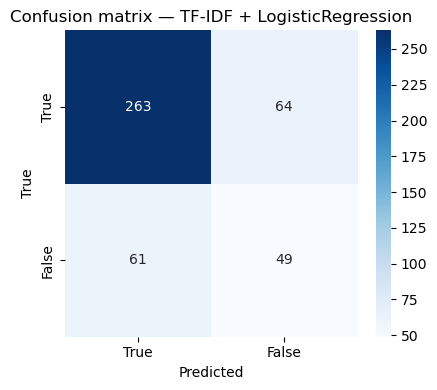

In [7]:
tfidf_logreg = Pipeline([
    ("tfidf", TfidfVectorizer(ngram_range=(1, 2), max_features=30000, sublinear_tf=True, min_df=2)),
    ("clf", LogisticRegression(max_iter=2000, class_weight="balanced")),
])

param_grid = {"clf__C": [0.1, 1.0, 3.0, 10.0]}
gs_logreg = GridSearchCV(tfidf_logreg, param_grid, cv=3, scoring="f1_macro", n_jobs=-1)
gs_logreg.fit(train_df["clean_text"], train_df["label"])
print("Best C:", gs_logreg.best_params_)

logreg_preds = gs_logreg.predict(test_df["clean_text"])
results.append(evaluate_predictions(test_df["label"], logreg_preds, "TF-IDF + LogisticRegression"))


Best C: {'clf__C': 0.1}
=== TF-IDF + LinearSVC ===
              precision    recall  f1-score   support

        True       0.82      0.81      0.81       327
       False       0.45      0.45      0.45       110

    accuracy                           0.72       437
   macro avg       0.63      0.63      0.63       437
weighted avg       0.72      0.72      0.72       437



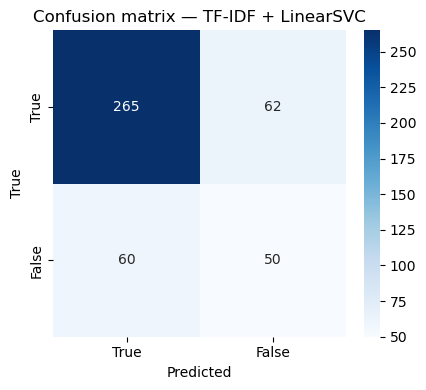

In [8]:
tfidf_svm = Pipeline([
    ("tfidf", TfidfVectorizer(ngram_range=(1, 2), max_features=30000, sublinear_tf=True, min_df=2)),
    ("clf", LinearSVC(class_weight="balanced")),
])

gs_svm = GridSearchCV(tfidf_svm, {"clf__C": [0.1, 1.0, 3.0, 10.0]}, cv=3, scoring="f1_macro", n_jobs=-1)
gs_svm.fit(train_df["clean_text"], train_df["label"])
print("Best C:", gs_svm.best_params_)

svm_preds = gs_svm.predict(test_df["clean_text"])
results.append(evaluate_predictions(test_df["label"], svm_preds, "TF-IDF + LinearSVC"))


## 6. Baseline B (stronger) — fine-tuned `aubmindlab/bert-base-arabertv02`


In [9]:
from transformers import (AutoTokenizer, AutoModelForSequenceClassification,
                           TrainingArguments, Trainer, DataCollatorWithPadding)
from datasets import Dataset

tokenizer = AutoTokenizer.from_pretrained(TRANSFORMER_MODEL)

def tokenize_fn(batch):
    return tokenizer(batch["clean_text"], truncation=True, max_length=128)

cols_keep = ["clean_text", "label_id"]
train_ds = Dataset.from_pandas(train_df[cols_keep].reset_index(drop=True))
val_ds   = Dataset.from_pandas(val_df[cols_keep].reset_index(drop=True))
test_ds  = Dataset.from_pandas(test_df[cols_keep].reset_index(drop=True))

train_ds = train_ds.map(tokenize_fn, batched=True)
val_ds   = val_ds.map(tokenize_fn, batched=True)
test_ds  = test_ds.map(tokenize_fn, batched=True)

train_ds = train_ds.rename_column("label_id", "labels")
val_ds   = val_ds.rename_column("label_id", "labels")
test_ds  = test_ds.rename_column("label_id", "labels")

keep_cols = ["input_ids", "attention_mask", "labels"]
train_ds.set_format(type="torch", columns=keep_cols)
val_ds.set_format(type="torch", columns=keep_cols)
test_ds.set_format(type="torch", columns=keep_cols)

data_collator = DataCollatorWithPadding(tokenizer=tokenizer)


Map:   0%|          | 0/2039 [00:00<?, ? examples/s]

Map:   0%|          | 0/437 [00:00<?, ? examples/s]

Map:   0%|          | 0/437 [00:00<?, ? examples/s]

In [11]:
def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=-1)
    acc = accuracy_score(labels, preds)
    p, r, f1, _ = precision_recall_fscore_support(labels, preds, average="macro", zero_division=0)
    return {"accuracy": acc, "macro_f1": f1, "macro_precision": p, "macro_recall": r}

model = AutoModelForSequenceClassification.from_pretrained(TRANSFORMER_MODEL, num_labels=NUM_LABELS)

training_args = TrainingArguments(
    output_dir=f"./{TASK_NAME}_finetuned",
    eval_strategy="epoch",   # transformers>=4.46 renamed this to eval_strategy
    save_strategy="epoch",
    learning_rate=2e-5,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=32,
    num_train_epochs=4,
    weight_decay=0.01,
    load_best_model_at_end=True,
    metric_for_best_model="macro_f1",
    fp16=torch.cuda.is_available(),
    logging_steps=50,
    report_to="none",
    seed=SEED,
)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_ds,
    eval_dataset=val_ds,
    processing_class=tokenizer,
    data_collator=data_collator,
    compute_metrics=compute_metrics,
)

trainer.train()


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertForSequenceClassification LOAD REPORT from: aubmindlab/bert-base-arabertv02
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Epoch,Training Loss,Validation Loss,Accuracy,Macro F1,Macro Precision,Macro Recall
1,0.538123,0.507202,0.762014,0.572407,0.688060,0.573122
2,0.471278,0.480371,0.771167,0.605880,0.707355,0.597082
3,0.389579,0.524688,0.771167,0.621133,0.700295,0.608965
4,0.317384,0.545439,0.762014,0.633153,0.676119,0.620654


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

TrainOutput(global_step=512, training_loss=0.431599254719913, metrics={'train_runtime': 20.8953, 'train_samples_per_second': 390.327, 'train_steps_per_second': 24.503, 'total_flos': 421319424614700.0, 'train_loss': 0.431599254719913, 'epoch': 4.0})

=== Fine-tuned bert-base-arabertv02 ===
              precision    recall  f1-score   support

        True       0.81      0.89      0.85       327
       False       0.53      0.37      0.44       110

    accuracy                           0.76       437
   macro avg       0.67      0.63      0.64       437
weighted avg       0.74      0.76      0.74       437



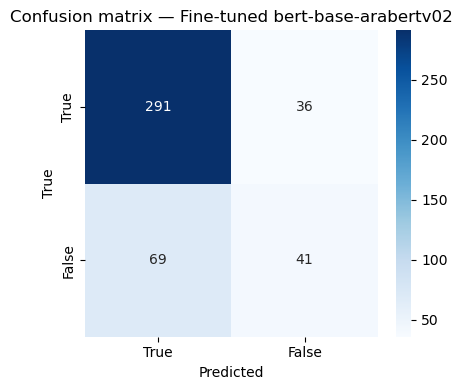

In [12]:
test_output = trainer.predict(test_ds)
transformer_preds_id = np.argmax(test_output.predictions, axis=-1)
transformer_preds = [id2label[i] for i in transformer_preds_id]

results.append(evaluate_predictions(test_df["label"], transformer_preds,
                                     f"Fine-tuned {TRANSFORMER_MODEL.split('/')[-1]}"))

# Keep these for the error-analysis section later
test_df["pred_transformer"] = transformer_preds


## 7. Zero-shot prompting with Jais (no fine-tuning)

We score each candidate label as a *continuation* of the prompt and pick the
one the model assigns the highest average log-probability to. This avoids
brittle free-text parsing and is the standard "rank classification" approach
for zero-shot evaluation of causal LMs.

> ⚠️ The prompt template below follows Inception AI's published Jais-chat
> format. Double-check it against the model card for whichever `JAIS_MODEL_NAME`
> checkpoint you select — chat templates occasionally differ across Jais
> releases (e.g. `jais-13b-chat-v1` vs the newer `jais-family-*-chat` models).


In [13]:
from transformers import AutoModelForCausalLM

jais_tokenizer = AutoTokenizer.from_pretrained(JAIS_MODEL_NAME)
jais_model = AutoModelForCausalLM.from_pretrained(
    JAIS_MODEL_NAME,
    trust_remote_code=True,
    torch_dtype=torch.float16 if torch.cuda.is_available() else torch.float32,
    device_map="auto",
)
jais_model.eval()


config.json:   0%|          | 0.00/1.33k [00:00<?, ?B/s]

configuration_jais.py:   0%|          | 0.00/9.52k [00:00<?, ?B/s]

[transformers] A new version of the following files was downloaded from https://huggingface.co/inceptionai/jais-family-590m-chat:
- configuration_jais.py
. Make sure to double-check they do not contain any added malicious code. To avoid downloading new versions of the code file, you can pin a revision.


tokenizer_config.json:   0%|          | 0.00/1.64k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/4.85M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/131 [00:00<?, ?B/s]

[transformers] `torch_dtype` is deprecated! Use `dtype` instead!


modeling_jais.py:   0%|          | 0.00/71.8k [00:00<?, ?B/s]

[transformers] A new version of the following files was downloaded from https://huggingface.co/inceptionai/jais-family-590m-chat:
- modeling_jais.py
. Make sure to double-check they do not contain any added malicious code. To avoid downloading new versions of the code file, you can pin a revision.


ImportError: cannot import name 'find_pruneable_heads_and_indices' from 'transformers.pytorch_utils' (/opt/conda/lib/python3.13/site-packages/transformers/pytorch_utils.py)

In [17]:
SYSTEM_PROMPT_AR = "أنت مساعد متخصص في تصنيف النصوص العربية. مهمتك تصنيف النص المعطى فقط، بدون أي شرح إضافي."
INSTRUCTION_AR = "هل النص التالي نكتة أم ليس نكتة؟ أجب بكلمة واحدة فقط."
LABEL_AR = {"not_joke": "ليست نكتة", "joke": "نكتة"}  # canonical label -> natural Arabic phrase used as the scored completion

def build_prompt(text: str) -> str:
    user_turn = f"[|Human|] {INSTRUCTION_AR}\nالنص: \"{text}\"\nالتصنيف:"
    return f"### Instruction: {SYSTEM_PROMPT_AR}\n### Input: {user_turn}\n### Response: [|AI|] "

print(build_prompt("نص تجريبي هنا"))


### Instruction: أنت مساعد متخصص في تصنيف النصوص العربية. مهمتك تصنيف النص المعطى فقط، بدون أي شرح إضافي.
### Input: [|Human|] هل النص التالي نكتة أم ليس نكتة؟ أجب بكلمة واحدة فقط.
النص: "نص تجريبي هنا"
التصنيف:
### Response: [|AI|] 


In [18]:
import torch.nn.functional as F

@torch.no_grad()
def score_candidate(prompt: str, candidate: str) -> float:
    """Average per-token log-prob the model assigns to `candidate`
    immediately following `prompt`. Higher = more likely completion."""
    full_text = prompt + candidate
    prompt_ids = jais_tokenizer(prompt, return_tensors="pt").input_ids.to(jais_model.device)
    full_ids = jais_tokenizer(full_text, return_tensors="pt").input_ids.to(jais_model.device)

    outputs = jais_model(full_ids)
    logits = outputs.logits[0]

    n_prompt_tokens = prompt_ids.shape[-1]
    target_ids = full_ids[0, n_prompt_tokens:]
    relevant_logits = logits[n_prompt_tokens - 1: -1, :]
    log_probs = F.log_softmax(relevant_logits.float(), dim=-1)
    token_log_probs = log_probs[torch.arange(len(target_ids)), target_ids]
    return token_log_probs.mean().item()


def zero_shot_classify(text: str):
    prompt = build_prompt(text)
    scores = [score_candidate(prompt, " " + LABEL_AR[lab]) for lab in LABELS]
    best_idx = int(np.argmax(scores))
    return LABELS[best_idx], scores


In [19]:
eval_pool = test_df.sample(
    n=min(ZERO_SHOT_SAMPLE_SIZE, len(test_df)) if ZERO_SHOT_SAMPLE_SIZE else len(test_df),
    random_state=SEED,
).reset_index(drop=True)

zero_shot_preds = []
for txt in tqdm(eval_pool["clean_text"], desc="Zero-shot scoring"):
    pred, _ = zero_shot_classify(txt)
    zero_shot_preds.append(pred)

eval_pool["pred_zero_shot"] = zero_shot_preds
results.append(evaluate_predictions(eval_pool["label"], zero_shot_preds,
                                     f"Zero-shot {JAIS_MODEL_NAME.split('/')[-1]}"))


Zero-shot scoring:   0%|          | 0/200 [00:00<?, ?it/s]

KeyError: True

### (Optional) Free-text generation, for qualitative inspection

The log-likelihood scoring above is the metric we report. This cell is just
useful if you want to see what the model *says* in its own words for a few
examples — handy for the paper's qualitative section.


In [ ]:
@torch.no_grad()
def generate_explanation(text: str, max_new_tokens: int = 40) -> str:
    prompt = build_prompt(text)
    input_ids = jais_tokenizer(prompt, return_tensors="pt").input_ids.to(jais_model.device)
    gen_ids = jais_model.generate(
        input_ids, max_new_tokens=max_new_tokens, do_sample=False,
        repetition_penalty=1.2, pad_token_id=jais_tokenizer.eos_token_id,
    )
    full = jais_tokenizer.decode(gen_ids[0], skip_special_tokens=True)
    return full[len(jais_tokenizer.decode(input_ids[0], skip_special_tokens=True)):].strip()

for txt in eval_pool["clean_text"].head(3):
    print("TEXT:", txt)
    print("MODEL SAYS:", generate_explanation(txt))
    print("---")


## 8. Comparison table


In [ ]:
results_df = pd.DataFrame(results).set_index("model")
results_df = results_df.round(3)
display(results_df)

ax = results_df[["accuracy", "macro_f1"]].plot(kind="bar", figsize=(8, 4))
ax.set_ylim(0, 1); ax.set_ylabel("Score"); ax.set_title("Joke Verification (Binary) — Arabic — model comparison")
plt.xticks(rotation=20, ha="right")
plt.tight_layout(); plt.show()

results_df.to_csv(f"{TASK_NAME}_results.csv")


## 9. Error analysis

For binary tasks, errors are by definition false positives or false negatives — look at whether the model is biased toward predicting `joke` (e.g. on sarcastic-but-serious text) or `not_joke` (e.g. on short, deadpan jokes with little surface markers like 'ههههه').

The cell below auto-detects the most-confused label pair from the **fine-tuned
transformer's** test predictions (usually the strongest model, so its
remaining mistakes are the most informative) and prints a few concrete
examples for both confusion directions — good source material for a
qualitative error-analysis subsection.


In [ ]:
def most_confused_pair(y_true, y_pred, labels):
    cm = confusion_matrix(y_true, y_pred, labels=labels)
    np.fill_diagonal(cm, 0)
    i, j = np.unravel_index(np.argmax(cm), cm.shape)
    return labels[i], labels[j], int(cm[i, j])

true_a, pred_b, n_confused = most_confused_pair(test_df["label"], test_df["pred_transformer"], LABELS)
print(f"Most common confusion: true='{true_a}' predicted as '{pred_b}' ({n_confused} cases)")

def show_examples(df_, true_label, pred_label, pred_col="pred_transformer", n=8):
    subset = df_[(df_["label"] == true_label) & (df_[pred_col] == pred_label)]
    cols = ["text", "label", pred_col]
    return subset[cols].head(n)

print(f"\nExamples: true={true_a} -> predicted={pred_b}")
display(show_examples(test_df, true_a, pred_b))

print(f"\nExamples (reverse direction): true={pred_b} -> predicted={true_a}")
display(show_examples(test_df, pred_b, true_a))


## 10. Notes for the paper

- Report the comparison table above as the main results table for this task.
- Use the auto-detected confusion pair + printed examples as concrete
  evidence in your qualitative error-analysis section.
- The zero-shot Jais numbers are a baseline-for-comparison, not a competitive
  system — expect it to trail both TF-IDF and the fine-tuned transformer
  unless the chosen Jais checkpoint is large; that gap is itself worth
  reporting as motivation for fine-tuning / future work.
